**Importing Modules**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df=pd.read_csv("../data/Student Social Media And Mental Health Impact.csv")

**EDA**

In [16]:
def structure():
    print(f"shape : {df.shape}")
    print(f"head :\n {df.head()}")
structure()

shape : (5000, 13)
head :
    Age  Gender Country Academic_Level Most_Used_Platform Purpose_Of_Use  \
0   21    Male   Other  Undergraduate           Facebook     Networking   
1   23  Female   Other       Graduate           LinkedIn      Education   
2   22    Male  Canada  Undergraduate          Instagram  Entertainment   
3   18    Male   Other    High School           Snapchat  Entertainment   
4   24  Female   Other       Graduate           Facebook     Networking   

   Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  Physical_Activity_Hours  \
0                    4.0            134          4.5                      2.2   
1                    1.6             73          7.0                      2.4   
2                    4.6            166          4.0                      1.8   
3                    7.0            220          1.0                      1.7   
4                    7.5            237          1.0                      1.1   

   Sleep_Hours_Per_Night Stress_Lev

In [17]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(2)

In [19]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


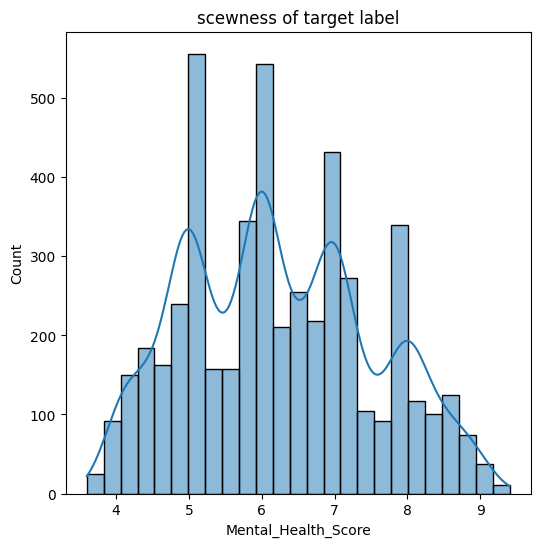

In [20]:
plt.figure(figsize=(6,6))
sns.histplot(df,x=df["Mental_Health_Score"],kde=True)
plt.title("scewness of target label")
plt.savefig("../reports/plots/scewness.png")
plt.show() 

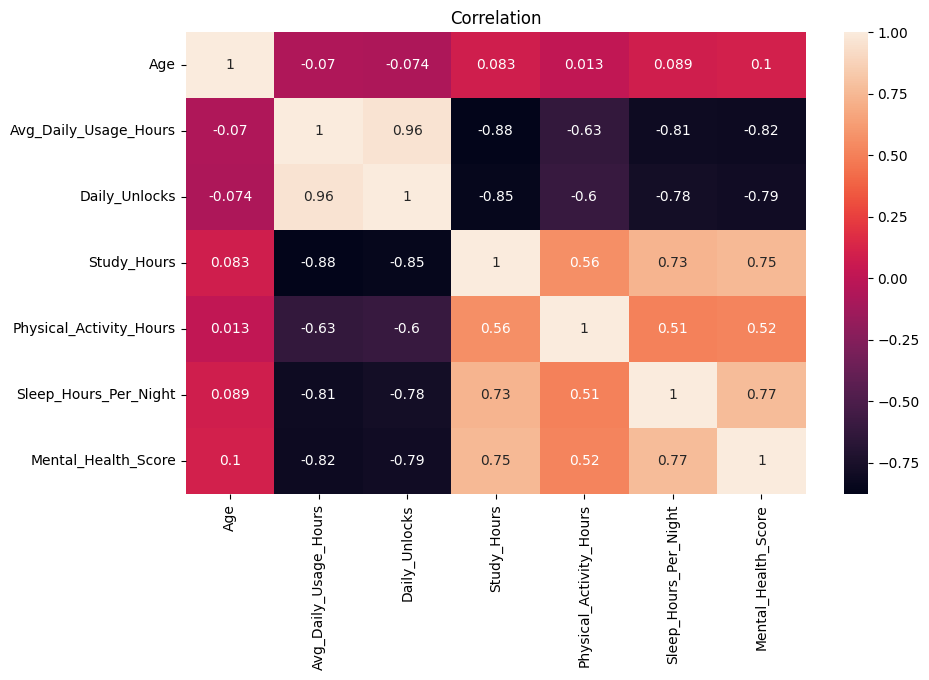

In [21]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True)
plt.title("Correlation")
plt.savefig("../reports/plots/Correlation.png",bbox_inches="tight")
plt.show()

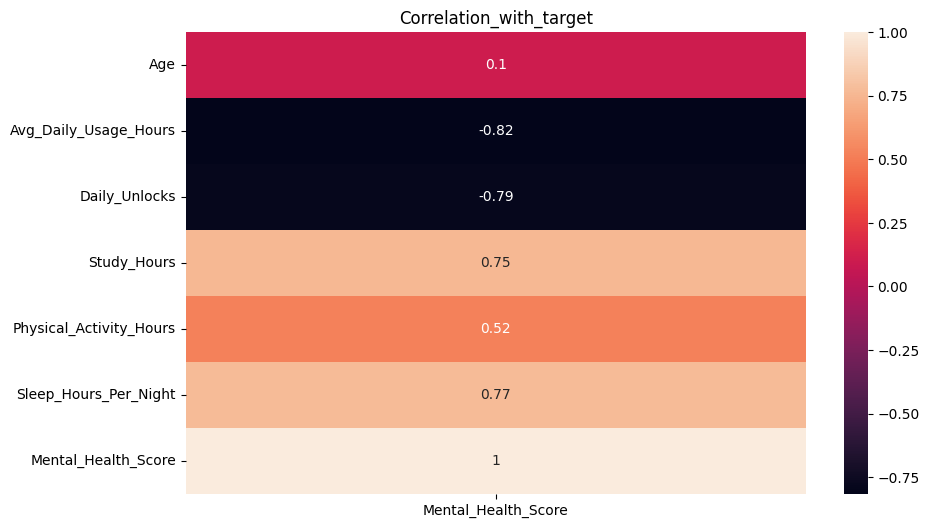

In [22]:
corr_with_target=df.corr(numeric_only=True)[["Mental_Health_Score"]]
plt.figure(figsize=(10,6))
sns.heatmap(corr_with_target,annot=True)
plt.title("Correlation_with_target")
plt.savefig("../reports/plots/Correlation_with_target.png",bbox_inches="tight")
plt.show()

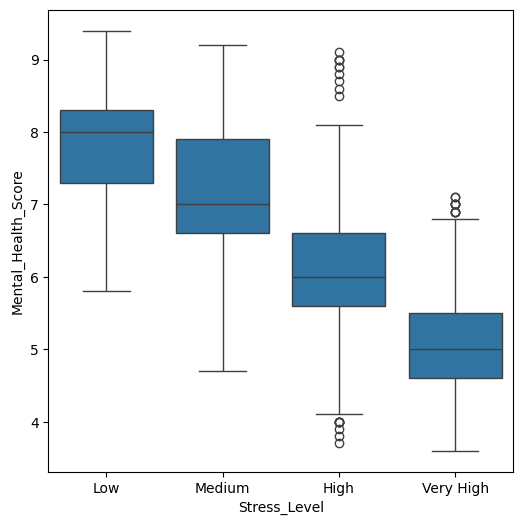

In [23]:
plt.figure(figsize=(6,6))
order=["Low","Medium","High","Very High"]
sns.boxplot(df,x=df["Stress_Level"],y=df["Mental_Health_Score"],order=order)
plt.savefig("../reports/plots/ouliers.png")
plt.show()

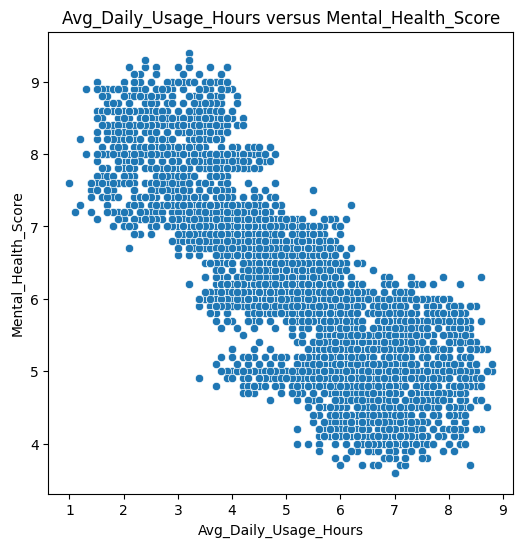

In [24]:
plt.figure(figsize=(6,6))
plt.title("Avg_Daily_Usage_Hours versus Mental_Health_Score")
sns.scatterplot(data=df,x=df["Avg_Daily_Usage_Hours"],y=df["Mental_Health_Score"])
plt.savefig("../reports/plots/score_vs_usage.png",bbox_inches="tight")
plt.show()


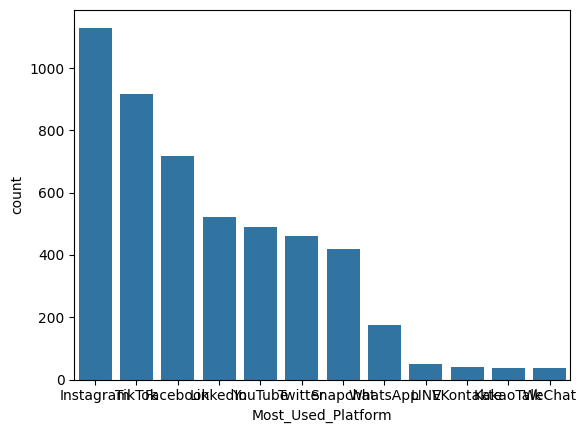

In [25]:
plt.Figure(figsize=(10,4))
sns.countplot(data=df,x=df["Most_Used_Platform"],order=df["Most_Used_Platform"].value_counts().index)
plt.savefig("../reports/plots/platforms.png")
plt.show()

**Checking Outliers**

In [26]:
numeric_features=df.select_dtypes(include="number")
Q1=numeric_features.quantile(0.25)
Q3=numeric_features.quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
higher_bound=Q3+1.5*IQR

Outliers= (numeric_features<lower_bound) | (numeric_features>higher_bound)
Outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64